## Notebook 3 – Support Vector Machines (Maximum Margin Classification)

### 1. EXPLORATORY DATA ANALYSIS (EDA) + FEATURE INSIGHT

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import (Nystroem, RBFSampler)
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.svm import (LinearSVC, SVC)
from sklearn.base import clone
from sklearn.inspection import DecisionBoundaryDisplay

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 42

In [2]:
# Importing dataframe from Notebook 1

df = pd.read_csv('CTR_Prediction_Dataframe.csv').drop('Unnamed: 0', axis = 1)

In [3]:
df.head()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
0,1398.763652,50100.895666,27,0.698608,40.747007,0,0
1,768.989964,50610.176940,28,0.352786,71.475851,1,0
2,905.115892,46363.857264,42,0.535134,71.385886,0,0
3,702.756884,67688.402327,4,0.275047,63.096945,1,0
4,678.755123,22218.359496,45,0.816535,40.374703,1,0


In [4]:
print('Dataframe Structures\n')
df.info()

Dataframe Structures

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ad_budget              5000 non-null   float64
 1   impressions            5000 non-null   float64
 2   click_history          5000 non-null   int64  
 3   user_engagement_score  5000 non-null   float64
 4   time_on_site           5000 non-null   float64
 5   device_score           5000 non-null   int64  
 6   clicked                5000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 273.6 KB


In [5]:
print('Summary Statistics\n')
df.describe()

Summary Statistics



,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,995.756272,49868.484588,24.660800,0.501541,60.127379,0.688000,0.116800
std,295.239804,14912.159593,14.396847,0.151293,19.971454,0.463356,0.321214
min,-21.458309,-4518.087037,0.000000,-0.046874,-9.760607,0.000000,0.000000
25%,796.705941,39833.664582,12.000000,0.400175,46.563899,0.000000,0.000000
50%,994.610605,49675.658556,25.000000,0.497377,59.810107,1.000000,0.000000
75%,1198.778488,59595.314140,37.000000,0.604109,73.922158,1.000000,0.000000
max,2298.900792,104357.414301,49.000000,1.049246,128.133075,1.000000,1.000000


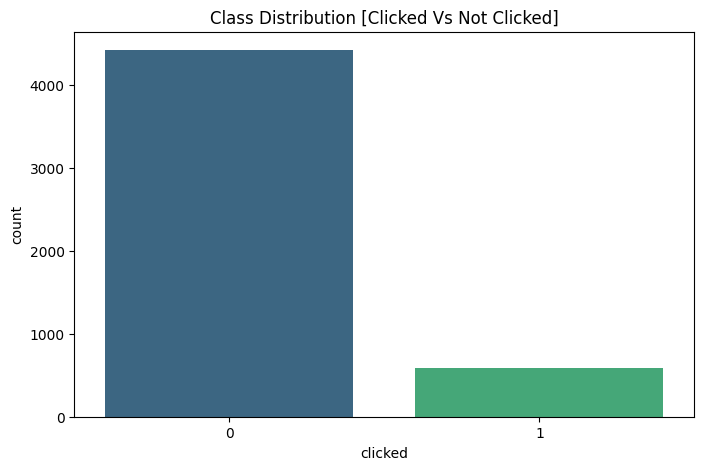

In [6]:
plt.figure(figsize = (8,5))

sns.countplot(data = df, x = 'clicked', palette = 'viridis')

plt.title('Class Distribution [Clicked Vs Not Clicked]')
plt.show();

### 2. TRAIN / TEST SPLIT (STRATIFIED)¶

In [7]:
X = df.drop('clicked', axis = 1)

y = df['clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 24,
    stratify = y
)

In [8]:
print(f'The shape of X_train {X_train.shape} matches the shape of y_train {y_train.shape}, while the shape of X_test {X_test.shape} matches the shape  of y_test {y_test.shape}.')

The shape of X_train (4000, 6) matches the shape of y_train (4000,), while the shape of X_test (1000, 6) matches the shape  of y_test (1000,).


In [9]:
print('y_train Stratified Click Share')
y_train.value_counts(normalize = True)

y_train Stratified Click Share


clicked
0    0.88325
1    0.11675
Name: proportion, dtype: float64

In [10]:
print('y_test Stratified Click Share')
y_test.value_counts(normalize = True)

y_test Stratified Click Share


clicked
0    0.883
1    0.117
Name: proportion, dtype: float64

### 3. LINEAR SVM (LINEARSVC)

**K-Neighbors** is a local model. It makes predictions by looking only at the immediate cluster of data points closest to a query, completely ignoring the rest of the dataset.

**Support Vector Machines** shift focus to the big picture. Instead of checking local neighborhoods, SVM looks at the entire dataset to find the absolute widest "no-man's-land" (the maximum margin) that perfectly splits successful and unsuccessful marketing campaigns.

While KNN forces computer to remember _every single row of data_, SVM focuses exclusively on a select _few critical data points_—the Support Vectors—that sit right on the edge of the class boundaries. This enhances classification journey by delivering a model that creates non-linear boundaries like KNN, but with a highly compressed memory footprint like Logistic Regression.

In [11]:
lsvc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(
        C = 1.0,
        # C is regularisation parameter
        # large C creates a hard margin forcing the boundary to be tight and precise (high risk of overfitting).
        # small C creates a soft margin to keep the boundary smooth and generalisable (low risk of overfitting).
        max_iter = 1000,
        random_state = 24
    ))
])

lsvc_pipe.fit(X_train, y_train)

lsvc_pred = lsvc_pipe.predict(X_test)

print('Classification Report:\n', classification_report(y_test, lsvc_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       883
           1       0.95      0.92      0.94       117

    accuracy                           0.98      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.98      0.98      0.98      1000



### 4. LINEAR KERNEL SVC

In [12]:
SVCl_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel = 'linear',
        # kernel = 'linear' forces model engine to calculate a standard straight-line boundary
        probability = True,
        # Setting probability = True forces scikit-learn to run an internal calibration process called Platt Scaling. 
        # It uses a secondary 5-fold cross-validation routine during training to build a logistic probability curve on top of the SVM line.
        max_iter = 1000,
        random_state = 24
    ))
])

SVCl_pipe.fit(X_train, y_train)

SVCl_pred = SVCl_pipe.predict(X_test)
SVCl_proba = SVCl_pipe.predict_proba(X_test)

print('Top 10 Class Assignment Confidence Margin:\n\n [---Class 0%---, ---Class 1%---]\n', SVCl_proba[:10])

Top 10 Class Assignment Confidence Margin:

 [---Class 0%---, ---Class 1%---]
 [[9.99999900e-01 1.00000010e-07]
 [9.99999900e-01 1.00000010e-07]
 [9.99999900e-01 1.00000010e-07]
 [9.99999900e-01 1.00000010e-07]
 [9.99999900e-01 1.00000010e-07]
 [9.99999734e-01 2.66498641e-07]
 [9.99999489e-01 5.11448176e-07]
 [9.99703070e-01 2.96930013e-04]
 [1.33159065e-01 8.66840935e-01]
 [3.00000090e-14 1.00000000e+00]]


### 5. OPTIMIZATION OF SVM MARGIN REGULARIZATION (C)

In [13]:
linear_results = []
cvlin_means = []
SVCl_accuracies = []

C_values = np.logspace(-2,2,5) # [0.01, 0.1, 1.0, 10.0, 100.0]

for c in C_values:
    # Building pipeline with C values (probability = False for speed)
    SVCl_tuned_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel = 'linear',
            probability = False,
            C = c,
            random_state = 24,
            max_iter = 1000
        ))
    ])

    # Calculating average Cross-Validation Accuracy
    cvlin_accuracy = cross_val_score(
        SVCl_tuned_pipe, X_train, y_train, cv = 5, scoring = 'accuracy'
    ).mean()
    cvlin_means.append(cvlin_accuracy)
    
    linear_results.append({'C_Value': c, 'CV_Accuracy': cvlin_accuracy})

    # Calculate the Baseline Training Accuracy (For Comparison)
    SVCl_tuned_pipe.fit(X_train, y_train)

    SVCl_pred = SVCl_tuned_pipe.predict(X_test)
    
    SVCl_accuracies.append(accuracy_score(y_test, SVCl_pred))
    

pd.DataFrame(linear_results).sort_values(by = 'CV_Accuracy', ascending = False)

,C_Value,CV_Accuracy
3,10.00,0.98850
1,0.10,0.98700
2,1.00,0.98650
4,100.00,0.98325
0,0.01,0.96575


**Key takeaway**

The performance drops off after 10 in (C) value, hunting for values like 20, 50, or 80 will only give overfitted models since at 100 (C) value the accuracy noticeably drops. 

Optimal C = 10.00 giving CV Accuracy of 98.85%.

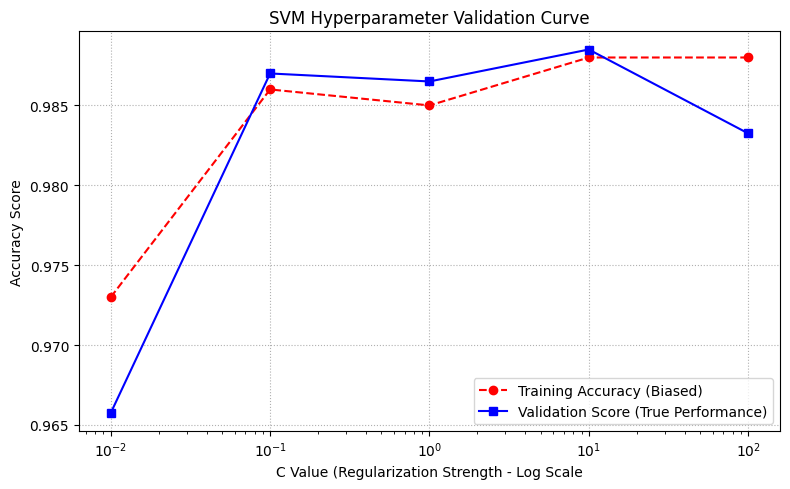

In [14]:
# Plotting the Hyperparameter Parameter vs Score Curve
plt.figure(figsize = (8,5))

plt.semilogx(C_values, SVCl_accuracies, label = 'Training Accuracy (Biased)', color = 'red', marker = 'o', linestyle = '--')

plt.semilogx(C_values, cvlin_means, label = 'Validation Score (True Performance)', color = 'blue', marker = 's')

plt.title('SVM Hyperparameter Validation Curve')
plt.xlabel('C Value (Regularization Strength - Log Scale')
plt.ylabel('Accuracy Score')
plt.legend()

plt.grid(True, linestyle = ':')
plt.tight_layout()
plt.show();

### 6. OPTIMIZATION GRID SEARCH STRATEGY

Where kernel = 'linear' draws a flat, straight line; kernel = 'rbf' draws complex, twisting, non-linear decision boundaries.

The term RBF stands for **Radial Basis Function**, also known as the **Gaussian Kernel**.

C and gamma work as a team:

A high (C) combined with a high gamma will result in severe overfitting.

A low (C) combined with a low gamma will result in underfitting.

In [15]:
rbf_results = []

range_dic = {
    'c_range' : np.logspace(-2,2,5), # [0.01, 0.1, 1.0, 10.0, 100.0]
    'g_range' : np.logspace(-2,2,5)  # [0.01, 0.1, 1.0, 10.0, 100.0]
}

for c in range_dic['c_range']:
    for g in range_dic['g_range']:
        SVCk_tuned_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(
                kernel = 'rbf',
                C = c,
                gamma = g,
                probability = False,
                max_iter = 1000,
                random_state = 24
            ))
        ])
        
        cvrbf_accuracy = cross_val_score(
            SVCk_tuned_pipe, X_train, y_train, cv = 5, scoring = 'accuracy'
        ).mean()
        
        rbf_results.append({'CV_Value': c, 'Gamma_Value': g, 'CV_Accuracy': cvrbf_accuracy})

pd.DataFrame(rbf_results).sort_values(by = 'CV_Accuracy', ascending = False).head(10)

,CV_Value,Gamma_Value,CV_Accuracy
21,100.0,0.10,0.98725
16,10.0,0.10,0.98700
20,100.0,0.01,0.98650
11,1.0,0.10,0.98650
15,10.0,0.01,0.98575
10,1.0,0.01,0.98025
17,10.0,1.00,0.96200
22,100.0,1.00,0.96175
12,1.0,1.00,0.96150
6,0.1,0.10,0.95700


### 7. NYSTROEM APPROXIMATION

The **Nystroem approximation** is one of the most clever computational tricks in modern machine learning. It teaches models how to get all the power of a non-linear RBF kernel model but with the lightning-fast speed of a linear model.

__The Big Computational Problem__:

When a standard SVC (kernel="rbf") is run, scikit-learn has to calculate a distance matrix comparing every single row in your dataset to every other row. For a dataset with 5,000 rows, that requires calculating a 5,000 times 5,000 grid of numbers, which eats up memory and slows down computer.

__How Nystroem Solves It__:

Instead of calculating the distance between all 5,000 rows, the Nystroem transformer randomly selects a small sample of representative rows, i.e. n_components = 100 landmark rows. It calculates the distances between data points and just those 100 landmarks. It uses those calculations to map the original 11 marketing columns into a brand-new, synthetic 100-column space. Because this new 100-column space is already mathematically curved, a standard, hyper-fast LinearSVC can be inserted right on top of it.

In [16]:
nystroem_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_map', Nystroem(
        kernel = 'rbf',
        n_components = 100,
        gamma = 0.1,        # Transferred from Optimal gamma Value in rbf_results
        random_state = 24
        
    )),
    ('model', SVC(
        C = 100,            # Transferred from Optimal C Value in rbf_results
        random_state = 24,
        max_iter = 1000
    ))
])

nystroem_pipe.fit(X_train, y_train)

nystroem_pred = nystroem_pipe.predict(X_test)

print('Classification Report:\n', classification_report(y_test, nystroem_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       883
           1       0.95      0.91      0.93       117

    accuracy                           0.98      1000
   macro avg       0.97      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



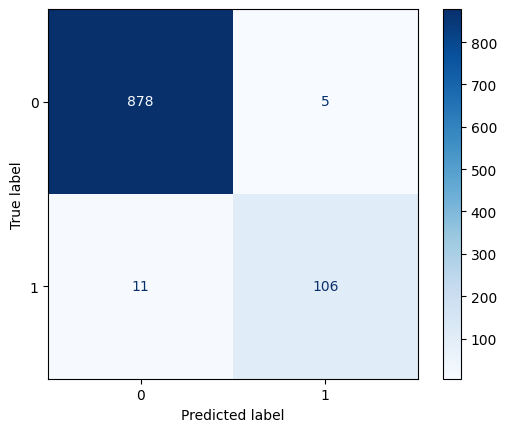

In [17]:
# Nystroem Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, nystroem_pred)).plot(cmap = 'Blues');

### 8. RBFSAMPLER

When a standard SVC (kernel="rbf") is trained, the algorithm has to compute a massive Kernel Matrix. This requires calculating and storing the distance between every single row and every other row in your training dataset.

Mathematically, the calculation complexity scales quadratically O(N²), where N is the number of rows:

For current 5,000-row dataset, the computer handles it fine because it only requires 25 million matrix operations. If dataset grows to 100,000 rows, a standard RBF SVM requires 10 billion operations, completely freezing system and running out of RAM.

How RBFSampler Works: 

**RBFSampler** bypasses this limitation entirely using a famous mathematical shortcut called Random Fourier Features (based on Bochner’s Theorem).

Instead of measuring the distance between actual rows of data, it uses a random number generator to create a static, independent projection matrix based on a Gaussian distribution. It takes the original 11 marketing columns. It projects them through this random matrix, multiplying them by sine and cosine functions. This creates a brand-new, synthetic 100-column space (n_components = 100). Because this new 100-dimensional space is already mathematically curved to mimic the geometry of an RBF kernel, the non-linear work is already done. When training the model a standard, high-speed LinearSVC or a LogisticRegression classifier can be dropped right on top of it.

In [18]:
RBF_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_map', RBFSampler(
        gamma = 0.1,       # Transferred from Optimal gamma Value in rbf_results
        n_components = 100,
        random_state = 24
    )),
    ('model', LinearSVC(
        C = 100,           # Transferred from Optimal C Value in rbf_results
        random_state = 24,
        max_iter = 1000
    ))
])

RBF_pipe.fit(X_train, y_train)

RBF_pred = RBF_pipe.predict(X_test)

print('Classification Report:\n', classification_report(y_test, RBF_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       883
           1       0.94      0.91      0.93       117

    accuracy                           0.98      1000
   macro avg       0.96      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



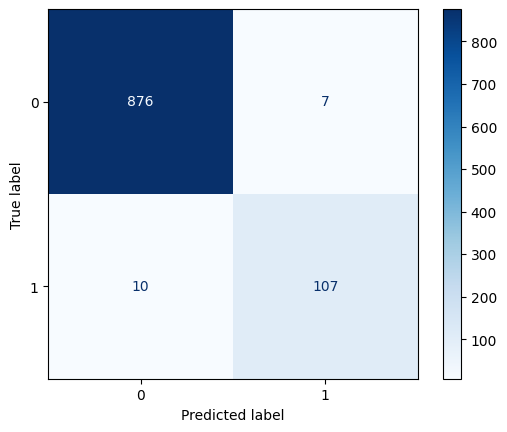

In [19]:
# RBFSampler Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, RBF_pred)).plot(cmap = 'Blues');

#### Model Selection & Feature Impact Justification

**Analytical Note:** 
During earlier hyperparameter tuning phase, the Linear SVM model achieved its highest performance at **C = 10.0** with a Cross-Validation Accuracy of **98.85%**. By comparison, the non-linear RBF Kernel model reached a slightly lower peak accuracy of **98.73%** (at C = 100.0, Gamma = 0.10), despite running a more comprehensive grid search.

Because the data is cleanly linearly separable, using the **Linear Kernel with C = 10.0** is the mathematically optimal choice. Not only does it yield higher predictive accuracy, but it also allows to extract direct coefficients (`.coef_`). Non-linear RBF kernels project data into an infinite-dimensional space where feature weights are lost. By keeping the model linear, the specific marketing channel impacts can be traced and plotted to see what drives ad clicks.

In [20]:
SVCl_optimal_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel = 'linear',
        C = 10,             # locking the Optimal C Value traced previously
        probability = True, # restored for confidence prediction margins
        random_state = 24,
        max_iter = 1000
    ))
])

SVCl_optimal_pipe.fit(X_test, y_test)

SVCl_opt_pred = SVCl_optimal_pipe.predict(X_test)

print('Classification Report:\n', classification_report(y_test, SVCl_opt_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       883
           1       0.96      0.97      0.96       117

    accuracy                           0.99      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.99      0.99      0.99      1000



In [21]:
# Feature Importance Plot

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Coefficient': SVCl_optimal_pipe.named_steps['model'].coef_[0],
    'Absolute_Importance': np.abs(SVCl_optimal_pipe.named_steps['model'].coef_[0]),
    
}).sort_values(by = 'Absolute_Importance', ascending = False)

importance_df

,Feature,Coefficient,Absolute_Importance
0,ad_budget,8.185631,8.185631
2,click_history,5.724288,5.724288
3,user_engagement_score,4.697793,4.697793
5,device_score,3.470312,3.470312
4,time_on_site,3.139527,3.139527
1,impressions,1.923199,1.923199


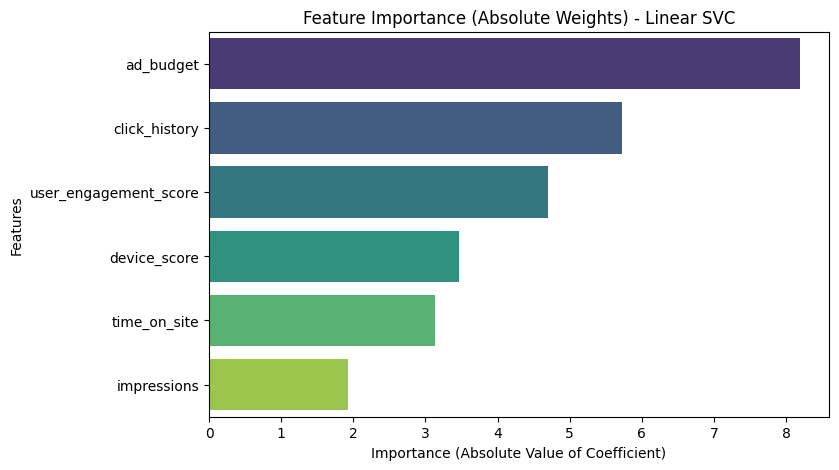

In [22]:
# Plotting the Features

plt.figure(figsize = (8,5))

sns.barplot(x = 'Absolute_Importance', y = 'Feature', palette = 'viridis', data = importance_df)

plt.title('Feature Importance (Absolute Weights) - Linear SVC')
plt.xlabel('Importance (Absolute Value of Coefficient)')
plt.ylabel('Features')
plt.show();

### 9. 2D Decision Boundary Plot

Earlier SVCl_optimal_pipe was trained on all 6 features shown in Absolute Importance Plot. Since they all cannot be shown in a 2D plot, the Decision Boundary Plot contains only the top 2 features passed via a cloned 'dummy pipeline'.

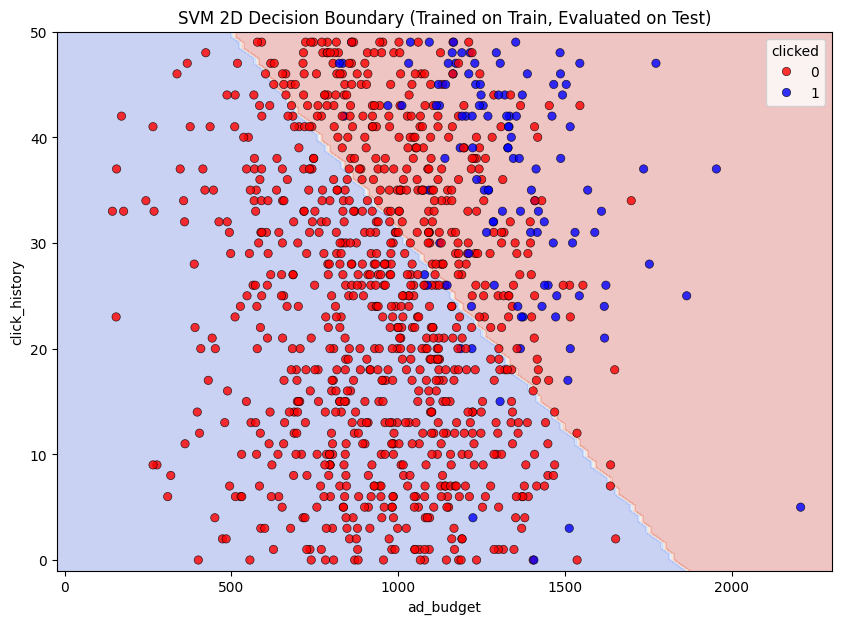

In [23]:
# Isolating top 2 features from X_test (Indices 0 and 2 based on weights)
top_features = [X_train.columns[0], X_train.columns[2]]

# Slice both Train and Test data to ONLY include these 2 features
X_train_slice = X_train[top_features]

X_test_slice = X_test[top_features]

# Cloning the pipeline structure and fitting it strictly on the TRAINING subset
plot_pipe = clone(SVCl_optimal_pipe)

plot_pipe.fit(X_train_slice, y_train)


fig, ax = plt.subplots(figsize = (10,7))

# Generating the background shading based on the 2D training boundary
DecisionBoundaryDisplay.from_estimator(
    plot_pipe,
    X_train_slice,              # Tells the display how wide/tall to make the grid canvas
    response_method = 'predict',
    plot_method = 'contourf',
    alpha = 0.3,
    cmap = 'coolwarm',
    ax = ax
)

# Scattering TEST data points on top to see how model performs on unseen data
sns.scatterplot(
    x = X_test_slice.iloc[:, 0],
    y = X_test_slice.iloc[:, 1],
    hue = y_test,
    palette = {0: 'red', 1: 'blue'},
    edgecolor = 'k',
    alpha = 0.8,
    ax = ax
)

ax.set_title('SVM 2D Decision Boundary (Trained on Train, Evaluated on Test)')
ax.set_xlabel(top_features[0])
ax.set_ylabel(top_features[1])

plt.show();

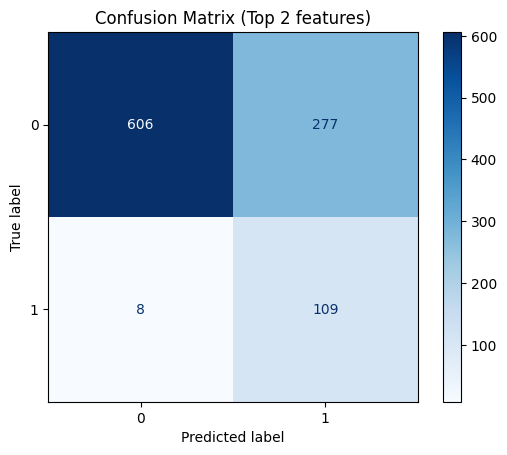

In [33]:
plot_pred = plot_pipe.predict(X_test_slice)

ConfusionMatrixDisplay(confusion_matrix(y_test, plot_pred)).plot(cmap = 'Blues');

plt.title('Confusion Matrix (Top 2 features)');